# Energy-Efficient & Carbon-Aware Cloud Task Scheduling
**Navaneetha Thalakokkula — MSc Cloud Computing, National College of Ireland**

A host-capacity simulation on the **real Google Cluster Trace 2011** and **real UK grid-carbon data**.
It compares three baselines (**FIFO/Round-Robin, Energy-aware consolidation, Carbon-aware greedy**) and
six metaheuristics (**WOA, GWO, PSO, DE, HHO, GA**), plus **CA-WOA** — a Carbon-Aware enhanced Whale
Optimization Algorithm — on energy, carbon, cost, SLA, utilisation and makespan.

**Platform:** Python · [Mealpy](https://github.com/thieu1995/mealpy) · NumPy · pandas · Matplotlib.

## 1. Install and import

In [1]:
!pip install -q --no-deps mealpy opfunu

import io, math, requests
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mealpy import FloatVar, WOA, GWO, PSO, DE, HHO, GA
SEED = 42; np.random.seed(SEED); rng = np.random.default_rng(SEED)
print("Mealpy ready.")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


Mealpy ready.


## 2. Energy model with servers (hosts)
A switched-on server draws idle power even when nearly empty, so energy depends on **how many servers are
active**. Packing tasks onto fewer servers (consolidation) saves energy:
$$ E_{slot} = \big(\text{active\_hosts}\cdot P_{idle} + (P_{max}-P_{idle})\cdot load\big)\cdot \Delta t. $$
Host capacity `C = 1.0` = one normalised machine (Google `cpu_request` is a fraction of the largest machine).

In [2]:
P_IDLE_W, P_MAX_W, SLOT_H, C = 100.0, 250.0, 0.5, 1.0

## 3. Real carbon intensity and cost
$$ CO_2 = \sum_{slot} E_{slot}\cdot CI_{slot}, \qquad Cost = \sum_{slot} E_{slot}\cdot price_{slot}. $$

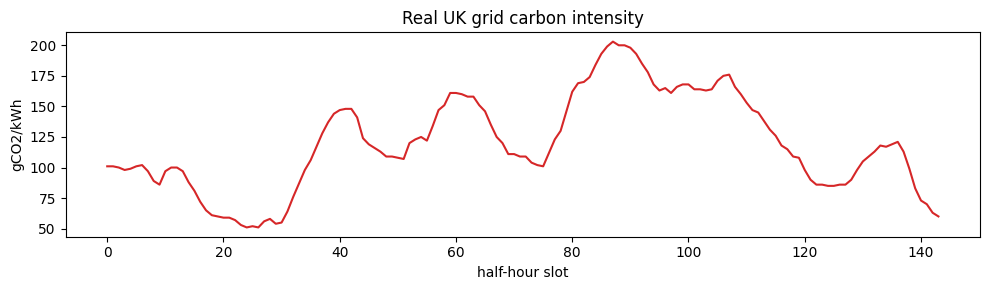

In [3]:
CI = np.array([101, 101, 100, 98, 99, 101, 102, 97, 89, 86, 97, 100, 100, 97, 88, 81, 72, 65, 61, 60, 59, 59, 57, 53, 51, 52, 51, 56, 58, 54, 55, 64, 76, 87, 98, 106, 117, 128, 137, 144, 147, 148, 148, 141, 124, 119, 116, 113, 109, 109, 108, 107, 120, 123, 125, 122, 134, 147, 151, 161, 161, 160, 158, 158, 151, 146, 135, 125, 120, 111, 111, 109, 109, 104, 102, 101, 112, 123, 130, 146, 162, 169, 170, 174, 184, 193, 199, 203, 200, 200, 198, 193, 185, 178, 168, 163, 165, 161, 166, 168, 168, 164, 164, 163, 164, 171, 175, 176, 166, 160, 153, 147, 145, 138, 131, 126, 118, 115, 109, 108, 98, 90, 86, 86, 85, 85, 86, 86, 90, 98, 105, 109, 113, 118, 117, 119, 121, 113, 99, 83, 73, 70, 63, 60], dtype=float)   # real UK grid carbon intensity (gCO2/kWh)
PRICE = np.full(len(CI), 0.15)
for day in range(len(CI)//48 + 1):
    for s in range(32, 40):
        k = day*48 + s
        if k < len(PRICE): PRICE[k] = 0.30
H = len(CI)
plt.figure(figsize=(10, 3)); plt.plot(CI, color="tab:red")
plt.title("Real UK grid carbon intensity"); plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh")
plt.tight_layout(); plt.show()

## 4. Real workload — Google Cluster Trace 2011

In [4]:
GOOGLE_TASKS = [{'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 4, 'u': 0.222, 'earliest': 0, 'deadline': 12}, {'dur': 4, 'u': 0.159, 'earliest': 0, 'deadline': 12}, {'dur': 1, 'u': 0.159, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.116, 'earliest': 0, 'deadline': 10}, {'dur': 4, 'u': 0.116, 'earliest': 0, 'deadline': 12}, {'dur': 1, 'u': 0.116, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.116, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.116, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.05, 'earliest': 0, 'deadline': 11}, {'dur': 2, 'u': 0.131, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.062, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.191, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 4, 'u': 0.062, 'earliest': 0, 'deadline': 12}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.062, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}]   # real tasks from the Google trace (fallback / reproducible)
def build_tasks(content):
    c = ["time","missing","job_id","task_index","machine_id","event_type","user","sched_class",
         "priority","cpu_request","mem_request","disk_request","constraint"]
    d = pd.read_csv(io.BytesIO(content), compression="gzip", header=None, names=c)
    s = (d[d.event_type==0][["job_id","task_index","time","cpu_request"]].dropna(subset=["cpu_request"])
         .rename(columns={"time":"submit"}).groupby(["job_id","task_index"], as_index=False).first())
    e = (d[d.event_type.isin([2,3,4,5])][["job_id","task_index","time"]]
         .rename(columns={"time":"end"}).groupby(["job_id","task_index"], as_index=False).first())
    mm = s.merge(e, on=["job_id","task_index"]); mm["dur_us"] = mm["end"] - mm["submit"]
    mm = mm[(mm.dur_us>0) & (mm.cpu_request>0)].reset_index(drop=True).head(60)
    lo, hi = mm.submit.min(), mm.submit.max(); out = []
    for _, r in mm.iterrows():
        du = int(np.clip(math.ceil(r.dur_us/1.8e9),1,12)); uu = round(float(np.clip(r.cpu_request,0.05,1.0)),3)
        ea = int((r.submit-lo)/(hi-lo+1)*(H//3)); out.append({"dur":du,"u":uu,"earliest":ea,"deadline":ea+du+8})
    return out
try:
    url = "https://storage.googleapis.com/clusterdata-2011-2/task_events/part-00000-of-00500.csv.gz"
    tasks = build_tasks(requests.get(url, timeout=120).content)
    print("Downloaded REAL Google Cluster Trace -> %d tasks" % len(tasks))
except Exception as ex:
    tasks = GOOGLE_TASKS; print("Using embedded real Google tasks: %d" % len(tasks))
N = len(tasks)
pd.DataFrame(tasks).head(6)

Downloaded REAL Google Cluster Trace -> 60 tasks


,dur,u,earliest,deadline
0,1,0.062,0,9
1,4,0.222,0,12
2,4,0.159,0,12
3,1,0.159,0,9
4,2,0.116,0,10
5,4,0.116,0,12


## 5. Host count (derived) + metrics
Number of servers **M is derived from the workload** — the minimum to run the baseline:
`M = ceil(peak per-slot demand under FIFO)`. Metrics: carbon, energy, cost, **SLA**, **utilisation**,
**makespan**, and capacity **overload** ($SLAV=\frac{\#\{finish>deadline\}}{N}\times100\%$).

In [5]:
MAX_DEFER = 24
def slot_loads(starts):
    load, count = {}, {}
    for t, s in zip(tasks, starts):
        for k in range(s, s+t["dur"]):
            if k < H: load[k] = load.get(k,0.0)+t["u"]; count[k] = count.get(k,0)+1
    return load, count

fifo_starts = [t["earliest"] for t in tasks]
M = math.ceil(max(slot_loads(fifo_starts)[0].values()))
print("Derived host count M =", M, "(capacity C =", C, "each)")

def evaluate(starts, consolidate=True):
    load, count = slot_loads(starts)
    carbon_g = cost = energy = overload = total = 0.0; util = []
    viol = sum(1 for t, s in zip(tasks, starts) if s + t["dur"] > t["deadline"])
    makespan = max((s + t["dur"]) for t, s in zip(tasks, starts))
    for k, ld in load.items():
        active = count[k] if not consolidate else max(1, math.ceil(ld / C))
        p = active*P_IDLE_W + (P_MAX_W-P_IDLE_W)*ld
        energy += p*SLOT_H/1000.0; carbon_g += p*SLOT_H/1000.0*CI[k]; cost += p*SLOT_H/1000.0*PRICE[k]
        util.append(ld/(active*C)); overload += max(0.0, ld-M); total += ld
    return {"Carbon_kgCO2": carbon_g/1000.0, "Energy_kWh": energy, "Cost_GBP": cost,
            "SLA_%": 100.0*viol/N, "Util_%": 100.0*np.mean(util) if util else 0.0,
            "Makespan_h": makespan*SLOT_H, "Overload_%": 100.0*overload/total if total else 0.0}

def decode(x):
    out = []
    for xi, t in zip(x, tasks):
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        out.append(t["earliest"] + int(round(xi*room)))
    return out

Derived host count M = 5 (capacity C = 1.0 each)


## 6. Baselines + carbon-aware scheduling
Fitness minimised by each algorithm: $F = \frac{CO_2}{CO_2^{base}} + 3\cdot\frac{SLAV}{100} + 3\cdot\frac{overload}{100}$.

In [6]:
base = evaluate(fifo_starts, consolidate=False)        # FIFO/Round-Robin (naive placement)
def cred(mm): return (base["Carbon_kgCO2"]-mm["Carbon_kgCO2"])/base["Carbon_kgCO2"]*100.0
def fitness(x):
    mm = evaluate(decode(x), consolidate=True)
    return (mm["Carbon_kgCO2"]/base["Carbon_kgCO2"]) + 3.0*(mm["SLA_%"]/100.0) + 3.0*(mm["Overload_%"]/100.0)
def run(model, starting=None):
    p = {"obj_func": fitness, "bounds": FloatVar(lb=[0.0]*N, ub=[1.0]*N), "minmax":"min", "log_to": None}
    g = model.solve(p, starting_solutions=starting, seed=SEED)
    return evaluate(decode(g.solution), consolidate=True)

def greedy_carbon_starts():
    out = []
    for t in tasks:
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        hi = max(0, min(room, t["deadline"] - t["dur"] - t["earliest"]))
        bo, bc = 0, float("inf")
        for o in range(0, hi+1):
            c = sum(CI[k] for k in range(t["earliest"]+o, t["earliest"]+o+t["dur"]) if k < H)
            if c < bc: bc, bo = c, o
        out.append(t["earliest"]+bo)
    return out

results = {"FIFO/Round-Robin (baseline)": base,
           "Energy-aware (consolidation)": evaluate(fifo_starts, consolidate=True),
           "Carbon-aware greedy": evaluate(greedy_carbon_starts(), consolidate=True)}
for name, cls in [("WOA",WOA.OriginalWOA),("GWO",GWO.OriginalGWO),("PSO",PSO.OriginalPSO),
                  ("DE",DE.OriginalDE),("HHO",HHO.OriginalHHO),("GA",GA.OriginalGA)]:
    results[name] = run(cls(epoch=120, pop_size=40)); print("ran", name)

ran WOA


ran GWO


ran PSO


ran DE


ran HHO
ran GA


## 7. CA-WOA — Carbon-Aware Whale Optimization
CA-WOA seeds part of WOA's initial population with a carbon-aware guess (each job near its lowest-carbon,
deadline-feasible slot), then optimises under the capacity constraint.

In [7]:
def greedy_x():
    return np.clip(np.array([(s-t["earliest"])/max(1, min(MAX_DEFER, H-t["dur"]-t["earliest"]))
                             for s, t in zip(greedy_carbon_starts(), tasks)]), 0, 1)
def carbon_aware_seeds(pop):
    g = greedy_x(); seeds = [g.copy()]
    for _ in range(pop//3): seeds.append(np.clip(g + rng.normal(0,0.10,N), 0, 1))
    while len(seeds) < pop: seeds.append(rng.uniform(0,1,N))
    return np.array(seeds[:pop])
results["CA-WOA"] = run(WOA.OriginalWOA(epoch=120, pop_size=40), starting=carbon_aware_seeds(40))
print("CA-WOA:", results["CA-WOA"])

CA-WOA: {'Carbon_kgCO2': 0.08399514999999998, 'Energy_kWh': 0.9325749999999997, 'Cost_GBP': 0.13988624999999993, 'SLA_%': 0.0, 'Util_%': 82.1, 'Makespan_h': 5.5, 'Overload_%': 0.0}


## 8. Comparison — all methods, all metrics

In [8]:
dfres = pd.DataFrame(results).T
dfres["CarbonReduction_%"] = [round(cred(results[i]),2) for i in dfres.index]
dfres.loc["FIFO/Round-Robin (baseline)", "CarbonReduction_%"] = 0.0
dfres = dfres[["CarbonReduction_%","SLA_%","Overload_%","Energy_kWh","Util_%","Makespan_h"]].round(2)
dfres

,CarbonReduction_%,SLA_%,Overload_%,Energy_kWh,Util_%,Makespan_h
FIFO/Round-Robin (baseline),0.00,0.00,0.0,5.03,10.00,2.0
Energy-aware (consolidation),80.51,0.00,0.0,0.98,75.13,2.0
Carbon-aware greedy,82.57,0.00,0.0,0.98,75.13,5.5
WOA,81.51,0.00,0.0,0.93,86.45,2.0
GWO,80.62,0.00,0.0,0.98,77.46,4.0
PSO,74.97,15.00,0.0,1.38,40.31,10.0
DE,72.91,23.33,0.0,1.63,32.28,12.5
HHO,81.59,0.00,0.0,0.93,83.52,2.5
GA,70.54,48.33,0.0,1.73,29.59,12.0
CA-WOA,83.44,0.00,0.0,0.93,82.10,5.5


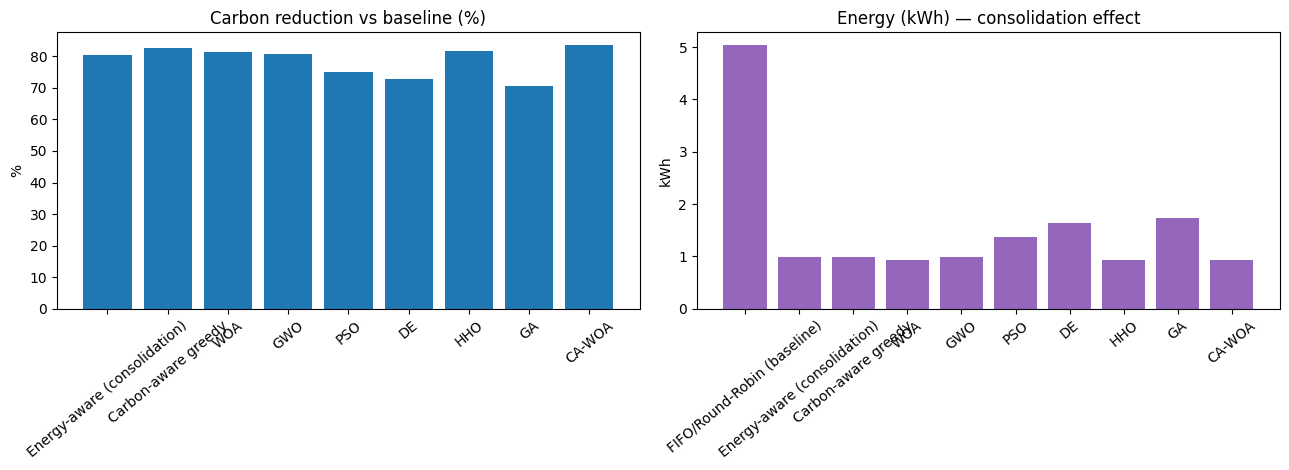

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
o = [i for i in dfres.index if i != "FIFO/Round-Robin (baseline)"]
ax[0].bar(o, dfres.loc[o,"CarbonReduction_%"], color="tab:blue"); ax[0].set(title="Carbon reduction vs baseline (%)", ylabel="%"); ax[0].tick_params(axis="x", rotation=40)
ax[1].bar(dfres.index, dfres["Energy_kWh"], color="tab:purple"); ax[1].set(title="Energy (kWh) — consolidation effect", ylabel="kWh"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

## 9. LSTM carbon forecasting (reactive → predictive)
So far the scheduler reacts to known carbon. Here we train an **LSTM** on ~111 days of real UK carbon
history to **predict future carbon intensity**, so the scheduler can plan toward *forecasted* clean windows.
We report accuracy on **held-out (unseen)** data.

2026-07-10 12:04:42.933855: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-10 12:04:42.952344: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/home/durga/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Training LSTM (~1 min)...


LSTM forecast MAE on UNSEEN data: 3.88 gCO2/kWh


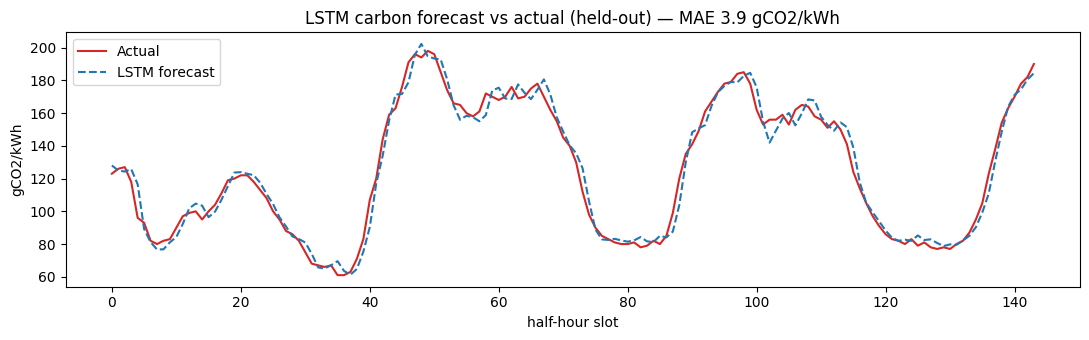

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
tf.random.set_seed(SEED)

CARBON_HISTORY = [90, 83, 76, 67, 66, 58, 56, 53, 50, 49, 50, 48, 47, 45, 47, 46, 51, 47, 51, 47, 47, 48, 47, 46, 46, 46, 46, 43, 39, 39, 42, 44, 52, 60, 70, 73, 72, 68, 66, 64, 62, 61, 61, 61, 57, 50, 49, 46, 45, 47, 48, 45, 46, 47, 46, 45, 44, 50, 51, 55, 62, 71, 74, 78, 79, 80, 82, 76, 74, 70, 65, 59, 62, 65, 67, 66, 63, 69, 87, 102, 121, 136, 143, 152, 154, 150, 139, 134, 127, 126, 125, 115, 113, 115, 120, 127, 133, 142, 145, 146, 148, 147, 150, 154, 154, 164, 178, 188, 208, 214, 204, 205, 198, 189, 184, 173, 166, 164, 161, 161, 159, 159, 166, 172, 175, 179, 191, 207, 218, 227, 237, 242, 240, 234, 233, 224, 220, 208, 200, 183, 175, 159, 145, 137, 139, 143, 143, 146, 146, 144, 142, 144, 143, 151, 156, 164, 173, 178, 173, 173, 174, 174, 167, 157, 152, 139, 129, 120, 118, 114, 115, 115, 114, 118, 122, 141, 156, 169, 178, 189, 192, 187, 184, 171, 163, 153, 144, 131, 119, 100, 83, 76, 79, 76, 74, 67, 72, 67, 67, 67, 72, 74, 82, 92, 107, 123, 127, 136, 136, 140, 136, 131, 127, 121, 118, 109, 105, 106, 112, 114, 119, 129, 136, 152, 162, 170, 172, 180, 184, 183, 174, 172, 168, 159, 156, 152, 147, 147, 149, 154, 158, 162, 162, 160, 160, 153, 149, 145, 152, 160, 178, 194, 212, 230, 240, 246, 243, 245, 242, 241, 240, 240, 237, 236, 236, 231, 229, 226, 226, 219, 223, 225, 224, 224, 231, 233, 235, 231, 227, 227, 222, 215, 213, 201, 196, 185, 179, 167, 168, 168, 164, 160, 156, 155, 154, 155, 157, 153, 153, 153, 152, 156, 164, 171, 172, 171, 172, 188, 176, 174, 172, 176, 176, 177, 177, 179, 182, 189, 195, 201, 205, 209, 213, 216, 218, 218, 221, 219, 218, 218, 211, 203, 194, 185, 176, 177, 179, 181, 179, 179, 178, 179, 180, 183, 185, 186, 177, 180, 184, 185, 191, 196, 197, 199, 200, 200, 196, 195, 196, 199, 200, 201, 200, 200, 201, 204, 209, 213, 222, 222, 223, 226, 225, 223, 218, 220, 217, 214, 208, 201, 187, 181, 174, 172, 174, 176, 178, 177, 175, 176, 175, 174, 177, 181, 186, 196, 220, 229, 226, 228, 229, 229, 227, 223, 219, 217, 219, 211, 210, 208, 204, 202, 204, 206, 210, 211, 215, 215, 219, 222, 222, 221, 217, 214, 214, 207, 201, 187, 173, 158, 146, 139, 145, 146, 145, 139, 136, 128, 126, 121, 126, 126, 127, 129, 143, 145, 142, 142, 142, 135, 128, 116, 109, 91, 78, 75, 74, 75, 78, 78, 81, 82, 92, 94, 98, 103, 110, 114, 125, 119, 102, 93, 85, 75, 78, 67, 73, 65, 64, 55, 51, 56, 54, 52, 51, 50, 48, 49, 51, 49, 50, 55, 59, 71, 71, 69, 65, 56, 52, 47, 45, 43, 41, 41, 39, 37, 40, 40, 45, 48, 52, 58, 62, 79, 89, 103, 111, 117, 112, 105, 96, 80, 81, 76, 86, 75, 79, 78, 79, 78, 68, 62, 56, 52, 51, 51, 51, 50, 54, 63, 70, 81, 66, 66, 60, 63, 70, 73, 73, 70, 70, 69, 65, 65, 68, 66, 68, 68, 71, 78, 79, 89, 93, 95, 95, 93, 94, 93, 93, 84, 72, 59, 59, 54, 46, 41, 44, 50, 45, 41, 40, 40, 41, 40, 39, 37, 37, 44, 47, 56, 57, 60, 66, 63, 61, 58, 57, 53, 48, 47, 53, 51, 51, 56, 53, 55, 59, 72, 94, 113, 125, 134, 143, 149, 149, 151, 156, 156, 151, 152, 150, 143, 129, 121, 123, 125, 128, 126, 128, 128, 127, 127, 124, 124, 125, 124, 129, 131, 135, 130, 126, 118, 107, 98, 93, 84, 75, 79, 77, 78, 82, 84, 92, 99, 113, 136, 159, 176, 188, 200, 216, 219, 216, 208, 207, 210, 206, 198, 190, 177, 171, 148, 143, 143, 139, 131, 120, 112, 93, 82, 91, 89, 93, 90, 90, 85, 74, 63, 51, 40, 36, 35, 35, 33, 29, 30, 32, 32, 35, 44, 50, 55, 53, 57, 55, 54, 59, 77, 80, 84, 77, 68, 66, 57, 51, 53, 56, 54, 53, 49, 51, 52, 53, 53, 52, 53, 53, 53, 53, 53, 54, 56, 62, 80, 82, 89, 94, 92, 89, 85, 84, 86, 86, 87, 89, 88, 90, 97, 95, 98, 100, 104, 110, 119, 127, 130, 142, 140, 131, 124, 120, 109, 93, 80, 76, 66, 70, 66, 66, 70, 66, 61, 61, 62, 58, 55, 59, 62, 74, 82, 90, 103, 97, 100, 89, 78, 71, 60, 76, 57, 53, 48, 46, 44, 42, 42, 42, 45, 53, 61, 68, 78, 89, 107, 115, 117, 109, 110, 112, 103, 92, 81, 73, 71, 66, 69, 87, 94, 94, 96, 99, 101, 101, 101, 96, 105, 113, 125, 144, 158, 164, 157, 146, 132, 123, 108, 95, 87, 82, 81, 76, 77, 78, 79, 80, 85, 97, 119, 146, 163, 176, 187, 190, 195, 199, 198, 198, 198, 191, 183, 178, 171, 167, 169, 169, 174, 177, 182, 184, 185, 191, 187, 194, 195, 195, 200, 204, 208, 207, 199, 186, 173, 157, 143, 134, 126, 119, 115, 111, 109, 109, 113, 116, 126, 142, 166, 183, 201, 209, 217, 221, 219, 219, 215, 219, 217, 209, 202, 197, 191, 180, 172, 172, 171, 171, 171, 171, 170, 168, 165, 164, 167, 176, 183, 183, 182, 185, 182, 177, 174, 166, 157, 147, 137, 132, 127, 124, 124, 125, 126, 128, 132, 139, 150, 171, 187, 195, 204, 205, 206, 210, 210, 209, 205, 201, 195, 188, 179, 173, 170, 173, 178, 181, 178, 174, 174, 176, 175, 176, 178, 178, 180, 182, 182, 176, 170, 164, 157, 152, 138, 125, 114, 105, 102, 99, 94, 92, 91, 93, 94, 106, 116, 139, 163, 178, 187, 194, 197, 194, 189, 188, 186, 183, 175, 162, 144, 128, 126, 129, 129, 119, 114, 109, 105, 101, 102, 101, 104, 109, 108, 108, 109, 103, 98, 97, 92, 91, 85, 80, 77, 77, 79, 80, 81, 86, 88, 93, 102, 118, 134, 150, 162, 171, 180, 185, 187, 190, 191, 192, 190, 186, 183, 174, 163, 162, 164, 162, 166, 170, 168, 164, 166, 170, 174, 174, 180, 199, 204, 219, 224, 211, 211, 207, 198, 190, 178, 161, 146, 132, 119, 121, 118, 116, 117, 126, 129, 130, 136, 140, 146, 154, 156, 168, 167, 160, 149, 138, 122, 113, 102, 100, 86, 78, 70, 69, 73, 71, 68, 68, 68, 66, 58, 55, 52, 52, 55, 64, 76, 60, 65, 65, 62, 65, 62, 63, 59, 60, 61, 58, 59, 57, 55, 53, 53, 52, 54, 53, 55, 57, 63, 69, 72, 68, 63, 63, 53, 51, 44, 43, 43, 36, 33, 34, 34, 38, 36, 36, 34, 36, 33, 32, 31, 30, 32, 35, 40, 43, 41, 38, 35, 37, 33, 33, 32, 35, 33, 35, 32, 32, 33, 34, 33, 26, 33, 42, 54, 59, 68, 74, 83, 88, 87, 85, 86, 75, 73, 68, 58, 56, 53, 67, 71, 67, 62, 65, 70, 71, 72, 65, 68, 78, 82, 95, 106, 114, 116, 111, 102, 100, 94, 92, 93, 91, 85, 85, 87, 89, 85, 85, 85, 92, 107, 133, 152, 163, 172, 182, 184, 185, 185, 190, 189, 176, 168, 150, 142, 141, 130, 129, 130, 131, 131, 128, 119, 118, 106, 114, 113, 113, 115, 126, 132, 124, 122, 113, 108, 101, 97, 89, 81, 80, 73, 68, 65, 62, 63, 65, 68, 67, 71, 80, 91, 113, 126, 133, 136, 130, 121, 113, 103, 92, 73, 65, 56, 72, 68, 67, 69, 70, 67, 60, 52, 47, 43, 48, 49, 51, 55, 62, 69, 67, 59, 47, 42, 39, 38, 32, 30, 31, 32, 34, 33, 33, 30, 30, 33, 38, 53, 65, 75, 80, 95, 99, 105, 105, 102, 92, 89, 90, 81, 67, 60, 51, 54, 60, 63, 75, 74, 68, 61, 62, 62, 72, 75, 95, 106, 113, 118, 116, 109, 91, 81, 71, 64, 65, 59, 55, 57, 58, 58, 57, 56, 53, 52, 52, 57, 61, 61, 59, 63, 55, 58, 55, 57, 56, 55, 57, 55, 47, 43, 44, 45, 40, 38, 39, 38, 37, 36, 37, 36, 45, 53, 53, 64, 71, 76, 68, 61, 56, 51, 47, 40, 36, 35, 39, 37, 35, 35, 35, 37, 38, 45, 52, 66, 76, 92, 103, 115, 121, 132, 135, 139, 139, 136, 126, 119, 100, 80, 81, 82, 78, 73, 71, 71, 62, 62, 59, 63, 91, 115, 144, 159, 164, 169, 158, 158, 162, 158, 152, 143, 138, 128, 121, 114, 117, 119, 115, 117, 122, 132, 141, 151, 158, 170, 183, 193, 201, 203, 197, 194, 195, 195, 194, 186, 173, 171, 170, 170, 166, 165, 166, 163, 164, 169, 170, 169, 177, 180, 182, 189, 186, 184, 177, 176, 168, 157, 149, 144, 140, 136, 133, 133, 131, 132, 134, 132, 131, 131, 135, 138, 148, 156, 170, 176, 174, 176, 171, 166, 167, 163, 161, 156, 142, 146, 148, 145, 144, 147, 141, 134, 123, 124, 130, 133, 138, 140, 154, 160, 163, 163, 144, 139, 131, 125, 118, 113, 106, 101, 102, 94, 92, 84, 84, 78, 73, 74, 81, 90, 111, 126, 139, 146, 158, 159, 152, 149, 153, 144, 146, 129, 112, 103, 94, 90, 88, 85, 83, 79, 82, 82, 71, 66, 64, 65, 72, 72, 73, 75, 61, 59, 60, 59, 60, 59, 56, 52, 49, 49, 48, 42, 42, 41, 32, 31, 33, 37, 45, 48, 48, 55, 49, 49, 49, 49, 48, 49, 62, 59, 48, 47, 51, 52, 58, 62, 55, 54, 50, 52, 56, 59, 67, 64, 66, 75, 76, 90, 101, 104, 105, 101, 99, 94, 93, 81, 66, 57, 52, 46, 42, 41, 37, 39, 41, 47, 59, 68, 72, 74, 77, 77, 74, 74, 68, 62, 59, 52, 54, 59, 59, 55, 50, 49, 47, 46, 45, 45, 53, 48, 42, 44, 45, 49, 49, 51, 50, 48, 49, 42, 41, 40, 43, 40, 33, 31, 37, 37, 32, 33, 35, 36, 38, 37, 40, 44, 48, 60, 64, 75, 82, 80, 76, 77, 79, 77, 71, 71, 70, 73, 78, 80, 83, 80, 72, 74, 84, 95, 96, 101, 103, 113, 121, 120, 122, 116, 98, 86, 75, 63, 60, 55, 53, 51, 50, 50, 52, 51, 49, 45, 52, 57, 60, 69, 71, 81, 95, 102, 97, 88, 82, 71, 62, 64, 60, 57, 59, 56, 56, 56, 56, 57, 57, 55, 56, 57, 61, 63, 78, 81, 76, 76, 70, 59, 53, 47, 42, 37, 35, 33, 31, 29, 25, 23, 21, 20, 27, 28, 31, 43, 50, 63, 77, 84, 88, 92, 85, 84, 87, 72, 69, 68, 74, 73, 71, 71, 74, 75, 73, 71, 79, 87, 95, 103, 132, 136, 142, 153, 162, 161, 154, 147, 142, 130, 113, 101, 92, 84, 83, 74, 67, 69, 73, 73, 77, 85, 101, 116, 127, 141, 150, 157, 160, 165, 167, 163, 163, 159, 148, 128, 117, 110, 113, 113, 113, 112, 113, 109, 112, 112, 113, 115, 123, 131, 132, 135, 131, 136, 139, 131, 109, 98, 94, 92, 85, 77, 70, 66, 63, 57, 61, 60, 59, 56, 56, 55, 54, 61, 63, 68, 65, 70, 69, 62, 52, 47, 42, 43, 45, 44, 44, 43, 43, 43, 36, 34, 33, 35, 34, 36, 47, 58, 80, 97, 116, 122, 125, 123, 121, 114, 118, 114, 110, 109, 104, 98, 90, 89, 90, 91, 95, 97, 94, 97, 115, 122, 126, 124, 122, 121, 118, 115, 105, 91, 90, 80, 80, 71, 69, 71, 70, 71, 63, 51, 46, 44, 45, 46, 45, 45, 47, 48, 54, 55, 55, 53, 49, 46, 44, 40, 39, 38, 39, 38, 37, 40, 41, 43, 42, 41, 42, 45, 45, 47, 54, 62, 71, 75, 79, 75, 70, 65, 67, 66, 67, 70, 70, 63, 60, 59, 61, 58, 52, 53, 53, 53, 57, 58, 52, 51, 56, 54, 47, 42, 47, 45, 56, 56, 53, 49, 41, 42, 40, 40, 41, 45, 47, 56, 64, 68, 83, 99, 118, 131, 138, 146, 146, 147, 138, 134, 139, 143, 145, 145, 144, 145, 140, 147, 143, 141, 143, 144, 149, 152, 161, 169, 180, 188, 201, 196, 180, 171, 162, 155, 145, 140, 134, 133, 130, 128, 123, 120, 116, 120, 118, 129, 136, 145, 158, 164, 174, 182, 186, 190, 190, 189, 187, 187, 189, 185, 177, 173, 177, 178, 177, 178, 179, 181, 182, 182, 186, 186, 188, 189, 197, 200, 191, 187, 173, 166, 157, 142, 126, 112, 96, 91, 86, 79, 77, 80, 84, 90, 91, 99, 107, 118, 126, 131, 136, 136, 140, 141, 144, 140, 142, 129, 117, 101, 78, 70, 75, 73, 73, 72, 68, 72, 75, 75, 76, 77, 76, 79, 91, 101, 111, 112, 90, 75, 75, 70, 66, 62, 60, 61, 60, 58, 57, 58, 65, 62, 59, 62, 63, 66, 68, 79, 84, 82, 88, 90, 95, 95, 87, 83, 77, 74, 75, 73, 76, 76, 74, 76, 70, 67, 67, 67, 71, 68, 80, 87, 96, 109, 105, 103, 86, 78, 73, 66, 67, 63, 64, 65, 63, 64, 64, 65, 66, 70, 73, 82, 92, 108, 123, 133, 133, 144, 148, 157, 164, 165, 166, 160, 156, 148, 129, 122, 115, 102, 92, 93, 96, 93, 96, 94, 98, 94, 101, 103, 106, 110, 98, 101, 97, 89, 77, 67, 68, 65, 59, 58, 55, 54, 56, 58, 58, 55, 52, 51, 59, 65, 75, 81, 89, 97, 105, 109, 111, 114, 107, 101, 104, 100, 98, 97, 92, 92, 85, 84, 84, 79, 78, 82, 88, 89, 89, 89, 92, 93, 91, 91, 80, 69, 77, 71, 63, 58, 53, 50, 50, 51, 49, 50, 46, 47, 50, 55, 61, 70, 80, 97, 111, 120, 125, 136, 133, 134, 132, 128, 126, 114, 101, 97, 96, 93, 91, 90, 86, 78, 79, 77, 80, 82, 85, 79, 85, 88, 93, 90, 82, 78, 73, 68, 64, 64, 64, 61, 63, 62, 67, 66, 69, 77, 79, 87, 94, 109, 125, 139, 146, 155, 161, 167, 170, 172, 173, 175, 171, 162, 161, 152, 147, 150, 147, 147, 145, 142, 142, 139, 132, 128, 139, 142, 164, 170, 171, 170, 164, 155, 144, 130, 119, 109, 105, 106, 104, 105, 110, 110, 111, 117, 119, 123, 122, 123, 127, 135, 136, 142, 147, 151, 154, 150, 148, 142, 136, 114, 98, 87, 86, 84, 82, 88, 79, 76, 78, 79, 79, 75, 80, 80, 94, 105, 104, 104, 105, 94, 84, 73, 66, 61, 55, 50, 44, 42, 42, 43, 45, 45, 47, 48, 41, 44, 50, 57, 66, 74, 79, 87, 94, 98, 90, 85, 78, 77, 68, 63, 64, 66, 67, 68, 68, 69, 73, 70, 73, 76, 80, 84, 88, 91, 70, 65, 68, 58, 52, 48, 46, 43, 42, 40, 40, 40, 37, 36, 37, 34, 27, 30, 29, 34, 43, 58, 61, 68, 82, 85, 91, 87, 81, 77, 84, 81, 72, 68, 73, 75, 75, 79, 79, 80, 84, 86, 87, 91, 93, 98, 103, 108, 118, 121, 118, 113, 106, 95, 82, 68, 57, 54, 51, 50, 50, 50, 52, 53, 56, 59, 65, 79, 92, 109, 123, 134, 139, 149, 152, 153, 153, 154, 146, 147, 150, 145, 145, 149, 147, 151, 152, 151, 146, 144, 142, 149, 153, 155, 156, 161, 168, 163, 156, 143, 134, 115, 94, 82, 68, 63, 64, 60, 60, 61, 62, 62, 64, 69, 77, 95, 117, 139, 145, 158, 170, 182, 192, 199, 199, 195, 195, 195, 183, 179, 175, 170, 163, 162, 159, 156, 153, 149, 147, 147, 140, 138, 142, 141, 136, 130, 125, 111, 97, 87, 77, 68, 67, 61, 58, 56, 54, 54, 56, 53, 56, 60, 67, 79, 97, 114, 128, 143, 150, 156, 162, 164, 163, 162, 164, 159, 144, 131, 124, 119, 113, 107, 103, 99, 97, 96, 91, 89, 81, 82, 90, 90, 97, 97, 93, 88, 85, 73, 67, 65, 63, 62, 64, 63, 61, 62, 62, 64, 72, 78, 93, 109, 133, 152, 160, 166, 171, 172, 172, 172, 175, 173, 167, 164, 160, 159, 158, 160, 161, 162, 162, 163, 162, 162, 164, 164, 168, 171, 174, 174, 178, 173, 166, 152, 136, 121, 107, 98, 92, 89, 85, 82, 89, 88, 89, 92, 100, 110, 118, 132, 153, 162, 169, 171, 166, 166, 180, 184, 190, 184, 176, 161, 141, 128, 119, 112, 110, 107, 108, 104, 102, 96, 87, 85, 83, 83, 91, 98, 100, 102, 105, 106, 109, 106, 103, 102, 93, 86, 79, 73, 72, 66, 64, 61, 58, 56, 57, 58, 66, 75, 76, 80, 84, 89, 86, 89, 87, 88, 89, 79, 75, 75, 75, 75, 75, 78, 80, 77, 72, 71, 69, 67, 61, 65, 68, 75, 75, 73, 69, 62, 58, 44, 40, 31, 31, 34, 40, 36, 36, 37, 37, 39, 36, 39, 39, 42, 45, 49, 50, 53, 49, 53, 48, 50, 55, 52, 47, 47, 43, 42, 43, 43, 43, 41, 41, 44, 42, 47, 46, 44, 43, 46, 54, 61, 59, 56, 49, 47, 46, 42, 41, 39, 34, 31, 32, 30, 28, 27, 27, 28, 27, 30, 30, 36, 42, 46, 54, 65, 73, 78, 70, 67, 65, 53, 51, 48, 49, 45, 49, 48, 50, 52, 49, 50, 50, 54, 57, 54, 57, 62, 76, 86, 98, 101, 95, 91, 91, 84, 81, 81, 80, 77, 75, 69, 71, 72, 72, 70, 73, 76, 86, 100, 119, 127, 134, 142, 154, 157, 150, 148, 157, 156, 145, 140, 118, 108, 110, 110, 107, 110, 108, 109, 106, 104, 101, 105, 103, 104, 120, 120, 119, 117, 115, 109, 110, 98, 86, 80, 77, 74, 77, 73, 73, 75, 79, 86, 95, 109, 125, 143, 159, 168, 178, 182, 184, 187, 178, 182, 182, 178, 170, 166, 156, 147, 147, 140, 135, 128, 123, 115, 114, 113, 124, 122, 120, 117, 117, 117, 123, 125, 124, 120, 124, 121, 122, 122, 118, 119, 119, 119, 120, 124, 127, 129, 132, 138, 146, 158, 163, 178, 185, 191, 198, 203, 206, 207, 205, 201, 200, 192, 181, 176, 175, 174, 174, 173, 174, 170, 170, 168, 174, 169, 173, 169, 172, 175, 171, 167, 151, 146, 143, 136, 131, 130, 128, 124, 121, 124, 126, 131, 132, 134, 134, 138, 143, 158, 171, 180, 189, 194, 195, 203, 207, 208, 208, 208, 209, 203, 191, 189, 191, 192, 195, 195, 197, 193, 193, 187, 187, 185, 190, 193, 196, 199, 191, 186, 182, 176, 166, 152, 143, 134, 127, 122, 123, 126, 131, 132, 132, 130, 133, 140, 142, 153, 156, 159, 164, 171, 172, 173, 170, 168, 170, 171, 170, 164, 150, 145, 145, 147, 154, 155, 154, 153, 153, 148, 143, 140, 151, 151, 150, 159, 156, 154, 147, 141, 132, 120, 111, 106, 106, 105, 102, 101, 103, 106, 114, 119, 131, 137, 152, 162, 172, 179, 178, 184, 186, 189, 197, 196, 196, 193, 188, 180, 177, 173, 173, 171, 171, 173, 168, 168, 171, 170, 172, 173, 174, 176, 178, 186, 180, 177, 173, 166, 161, 151, 144, 142, 141, 137, 136, 136, 134, 134, 129, 133, 135, 141, 144, 147, 156, 162, 167, 172, 183, 187, 190, 190, 189, 189, 192, 187, 186, 185, 183, 184, 185, 189, 191, 191, 192, 191, 193, 197, 192, 195, 197, 200, 194, 188, 185, 176, 166, 159, 153, 150, 145, 140, 137, 134, 128, 127, 127, 128, 129, 133, 141, 150, 160, 169, 174, 180, 187, 191, 195, 198, 198, 196, 192, 182, 166, 161, 161, 160, 163, 163, 162, 161, 158, 160, 163, 163, 160, 151, 145, 139, 126, 113, 106, 94, 85, 77, 73, 71, 68, 65, 66, 66, 67, 66, 64, 68, 68, 74, 81, 92, 107, 123, 138, 143, 150, 158, 163, 163, 165, 166, 170, 165, 144, 129, 122, 115, 110, 108, 107, 105, 96, 93, 85, 80, 74, 73, 80, 79, 85, 82, 79, 73, 69, 67, 62, 62, 61, 60, 60, 57, 56, 55, 55, 55, 54, 53, 55, 63, 78, 92, 102, 111, 122, 131, 136, 141, 140, 139, 140, 132, 119, 114, 112, 113, 112, 112, 106, 104, 106, 108, 108, 98, 100, 102, 115, 129, 128, 128, 112, 110, 97, 90, 92, 93, 91, 92, 95, 93, 91, 86, 83, 85, 84, 87, 94, 98, 104, 113, 114, 118, 123, 126, 132, 134, 140, 140, 138, 118, 102, 98, 97, 96, 95, 95, 86, 85, 83, 74, 76, 76, 84, 83, 88, 95, 88, 82, 74, 62, 55, 47, 44, 39, 40, 37, 35, 36, 35, 35, 34, 32, 36, 40, 55, 62, 74, 86, 101, 113, 123, 135, 134, 139, 138, 129, 121, 112, 97, 82, 76, 73, 76, 77, 79, 83, 81, 75, 80, 80, 86, 83, 85, 102, 102, 100, 87, 83, 82, 78, 78, 83, 81, 81, 80, 78, 79, 82, 79, 84, 90, 97, 106, 116, 132, 145, 149, 162, 163, 165, 163, 164, 166, 163, 167, 161, 132, 115, 104, 92, 92, 94, 87, 89, 88, 92, 91, 89, 86, 94, 91, 107, 114, 111, 104, 102, 100, 91, 80, 77, 69, 65, 67, 64, 61, 58, 57, 61, 70, 69, 69, 83, 100, 113, 130, 138, 147, 154, 159, 164, 165, 163, 169, 162, 151, 139, 129, 118, 110, 98, 91, 90, 91, 89, 88, 91, 93, 88, 95, 101, 93, 94, 84, 77, 71, 64, 62, 60, 61, 58, 57, 58, 61, 61, 59, 59, 62, 66, 70, 83, 98, 115, 129, 139, 144, 153, 163, 169, 163, 161, 169, 169, 157, 149, 157, 154, 153, 153, 150, 150, 146, 140, 138, 142, 142, 137, 142, 144, 146, 149, 148, 141, 136, 129, 130, 133, 134, 134, 135, 135, 137, 138, 139, 144, 149, 153, 157, 164, 165, 168, 169, 169, 167, 165, 161, 158, 158, 155, 151, 137, 121, 112, 110, 108, 101, 95, 90, 89, 91, 93, 98, 100, 108, 101, 91, 89, 86, 81, 84, 83, 80, 75, 78, 77, 72, 71, 69, 69, 70, 71, 70, 71, 76, 80, 88, 100, 124, 140, 153, 166, 167, 171, 180, 186, 195, 197, 195, 195, 195, 199, 200, 198, 196, 202, 201, 197, 200, 201, 200, 204, 217, 221, 226, 223, 218, 213, 211, 204, 200, 194, 190, 188, 184, 177, 172, 166, 162, 157, 155, 154, 148, 148, 154, 161, 165, 170, 167, 167, 169, 167, 172, 173, 176, 169, 148, 123, 96, 81, 73, 65, 60, 61, 56, 53, 54, 52, 50, 51, 52, 56, 66, 75, 71, 73, 73, 69, 67, 66, 63, 60, 58, 61, 59, 53, 53, 53, 49, 49, 44, 47, 52, 55, 66, 75, 76, 82, 85, 87, 89, 91, 88, 80, 75, 68, 65, 59, 59, 58, 57, 56, 57, 57, 55, 54, 52, 51, 54, 59, 56, 67, 77, 79, 75, 70, 65, 60, 64, 55, 55, 56, 56, 56, 59, 60, 60, 64, 65, 68, 74, 82, 91, 103, 107, 114, 121, 127, 132, 136, 142, 139, 140, 129, 112, 110, 114, 111, 106, 104, 102, 104, 98, 93, 93, 94, 107, 115, 120, 121, 118, 124, 126, 120, 114, 104, 90, 78, 67, 62, 60, 58, 57, 56, 60, 63, 60, 61, 72, 86, 105, 127, 140, 153, 166, 177, 183, 187, 191, 188, 189, 182, 177, 169, 162, 157, 148, 141, 136, 138, 141, 142, 139, 131, 127, 124, 122, 122, 110, 107, 99, 93, 80, 71, 68, 68, 65, 59, 57, 57, 54, 53, 50, 51, 49, 51, 55, 66, 75, 96, 118, 127, 136, 144, 152, 156, 154, 153, 146, 142, 124, 113, 104, 96, 96, 94, 99, 103, 91, 101, 101, 93, 106, 107, 118, 124, 118, 117, 118, 111, 105, 97, 87, 73, 68, 65, 63, 65, 61, 59, 63, 63, 71, 70, 79, 89, 103, 122, 139, 154, 164, 180, 187, 191, 191, 191, 189, 187, 180, 177, 174, 168, 170, 169, 165, 164, 159, 157, 160, 160, 158, 155, 154, 151, 134, 124, 114, 104, 92, 81, 73, 70, 67, 64, 62, 59, 60, 60, 59, 56, 57, 61, 73, 90, 109, 123, 143, 162, 167, 175, 183, 192, 202, 204, 200, 189, 175, 170, 161, 159, 153, 150, 149, 147, 146, 144, 136, 133, 133, 132, 136, 133, 130, 123, 117, 111, 98, 90, 83, 76, 75, 75, 74, 77, 73, 73, 72, 76, 78, 82, 89, 106, 122, 134, 142, 150, 155, 165, 174, 177, 178, 176, 175, 173, 165, 162, 165, 165, 169, 166, 169, 170, 164, 163, 165, 165, 170, 174, 173, 173, 177, 170, 172, 165, 155, 148, 139, 131, 128, 126, 123, 124, 124, 124, 123, 126, 130, 132, 136, 146, 150, 153, 169, 176, 184, 187, 193, 195, 195, 203, 198, 185, 168, 156, 146, 144, 140, 135, 129, 126, 123, 119, 122, 130, 137, 139, 141, 142, 143, 137, 132, 125, 117, 101, 93, 81, 69, 63, 59, 59, 58, 57, 56, 55, 54, 55, 61, 69, 78, 92, 109, 119, 126, 134, 138, 144, 148, 149, 146, 139, 128, 120, 117, 113, 110, 105, 103, 97, 96, 97, 99, 99, 106, 114, 113, 116, 96, 85, 77, 66, 60, 55, 52, 51, 52, 52, 52, 51, 50, 51, 50, 50, 46, 48, 45, 55, 70, 79, 101, 109, 110, 112, 121, 124, 123, 126, 127, 118, 96, 93, 82, 80, 82, 83, 90, 97, 99, 100, 95, 100, 104, 111, 119, 120, 122, 122, 118, 113, 108, 100, 95, 88, 86, 82, 75, 68, 67, 66, 67, 61, 61, 63, 71, 83, 107, 120, 144, 159, 163, 176, 191, 196, 194, 198, 196, 185, 174, 166, 165, 160, 158, 161, 172, 170, 168, 170, 176, 169, 170, 175, 178, 170, 162, 155, 145, 140, 130, 112, 98, 90, 85, 83, 81, 80, 80, 81, 78, 79, 82, 80, 85, 99, 120, 135, 141, 149, 161, 167, 173, 178, 179, 184, 185, 178, 162, 153, 156, 156, 159, 153, 162, 165, 164, 158, 156, 151, 155, 150, 141, 124, 114, 105, 97, 91, 86, 83, 82, 80, 83, 79, 81, 78, 77, 78, 77, 80, 82, 87, 95, 105, 123, 138, 154, 163, 170, 178, 182, 190, 193, 193, 191, 191, 193, 189, 188, 188, 188, 188, 186, 183, 185, 183, 178, 175, 175, 175, 177, 174, 164, 161, 148, 143, 138, 134, 123, 120, 116, 113, 108, 104, 101, 98, 101, 106, 109, 117, 129, 140, 156, 163, 174, 177, 186, 190, 189, 192, 186, 186, 181, 179, 178, 168, 163, 170, 169, 171, 175, 179, 184, 192, 198, 201, 202, 202, 197, 198, 194, 193, 195, 191, 187, 179, 167, 158, 148, 143, 140, 135, 131, 130, 133, 134, 139, 145, 150, 159, 165, 166, 163, 173, 183, 189, 191, 193, 191, 190, 185, 179, 153, 140, 128, 114, 112, 113, 117, 120, 124, 127, 125, 125, 121, 130, 137, 138, 138, 134, 126, 110, 99, 89, 83, 76, 64, 58, 50, 48, 46, 47, 44, 39, 39, 39, 39, 39, 46, 51, 54, 60, 57, 61, 62, 62, 60, 61, 63, 65, 66, 69, 70, 70, 73, 73, 70, 71, 68, 67, 65, 64, 63, 66, 73, 71, 76, 77, 73, 69, 66, 62, 65, 63, 61, 59, 57, 54, 52, 54, 56, 58, 54, 54, 51, 50, 58, 54, 58, 65, 64, 70, 80, 82, 79, 77, 84, 74, 65, 65, 66, 64, 61, 63, 62, 62, 59, 61, 61, 61, 62, 70, 68, 79, 85, 82, 86, 83, 77, 81, 81, 77, 77, 77, 78, 78, 77, 77, 80, 83, 83, 90, 96, 117, 133, 142, 154, 157, 165, 172, 177, 180, 178, 173, 168, 160, 149, 144, 139, 139, 135, 129, 127, 118, 102, 89, 83, 78, 69, 72, 72, 66, 75, 72, 73, 67, 64, 62, 60, 58, 60, 60, 64, 66, 61, 63, 61, 62, 66, 68, 72, 80, 85, 94, 98, 107, 120, 125, 128, 128, 126, 122, 112, 101, 98, 97, 92, 89, 88, 90, 91, 87, 82, 78, 77, 75, 72, 75, 78, 75, 76, 75, 68, 62, 61, 56, 55, 52, 52, 52, 49, 49, 50, 47, 50, 50, 50, 54, 59, 71, 86, 90, 99, 107, 113, 119, 118, 119, 124, 125, 119, 114, 113, 110, 114, 115, 110, 107, 114, 117, 115, 112, 117, 117, 123, 130, 129, 135, 142, 143, 144, 139, 137, 135, 131, 126, 119, 115, 115, 110, 105, 98, 95, 99, 111, 109, 111, 122, 130, 138, 155, 166, 175, 178, 185, 188, 180, 178, 176, 167, 146, 137, 120, 108, 101, 101, 100, 98, 99, 101, 102, 97, 89, 86, 97, 100, 100, 97, 88, 81, 72, 65, 61, 60, 59, 59, 57, 53, 51, 52, 51, 56, 58, 54, 55, 64, 76, 87, 98, 106, 117, 128, 137, 144, 147, 148, 148, 141, 124, 119, 116, 113, 109, 109, 108, 107, 120, 123, 125, 122, 134, 147, 151, 161, 161, 160, 158, 158, 151, 146, 135, 125, 120, 111, 111, 109, 109, 104, 102, 101, 112, 123, 130, 146, 162, 169, 170, 174, 184, 193, 199, 203, 200, 200, 198, 193, 185, 178, 168, 163, 165, 161, 166, 168, 168, 164, 164, 163, 164, 171, 175, 176, 166, 160, 153, 147, 145, 138, 131, 126, 118, 115, 109, 108, 98, 90, 86, 86, 85, 85, 86, 86, 90, 98, 105, 109, 113, 118, 117, 119, 121, 113, 99, 83, 73, 70, 63, 60, 62, 61, 64, 65, 67, 64, 64, 62, 69, 71, 75, 89, 93, 103, 97, 91, 82, 73, 62, 63, 70, 63, 61, 61, 59, 60, 50, 49, 51, 49, 49, 54, 54, 60, 60, 62, 70, 80, 86, 92, 96, 99, 100, 95, 93, 91, 93, 89, 83, 73, 87, 84, 74, 68, 59, 60, 56, 58, 54, 52, 53, 49, 51, 51, 49, 46, 48, 44, 44, 43, 43, 42, 38, 40, 38, 38, 40, 41, 44, 51, 45, 48, 48, 53, 57, 64, 75, 78, 84, 78, 69, 69, 72, 72, 80, 80, 88, 92, 95, 93, 93, 92, 96, 98, 98, 98, 102, 101, 97, 94, 87, 86, 78, 75, 75, 73, 72, 71, 68, 70, 69, 69, 66, 67, 70, 71, 72, 79, 89, 102, 110, 128, 141, 142, 152, 152, 156, 162, 159, 152, 134, 129, 123, 124, 129, 133, 129, 129, 134, 135, 139, 138, 134, 140, 145, 159, 162, 162, 158, 155, 146, 137, 125, 122, 128, 125, 121, 119, 119, 121, 122, 124, 126, 130, 140, 154, 163, 170, 173, 178, 181, 185, 189, 192, 194, 191, 198, 199, 196, 192, 197, 199, 194, 199, 202, 202, 202, 205, 210, 209, 209, 207, 207, 207, 203, 200, 198, 191, 183, 174, 165, 159, 150, 143, 139, 134, 131, 131, 131, 131, 136, 141, 142, 145, 155, 163, 167, 169, 171, 167, 167, 169, 170, 170, 174, 171, 167, 164, 165, 167, 166, 166, 164, 162, 162, 159, 160, 159, 166, 163, 151, 148, 134, 131, 127, 121, 111, 98, 84, 80, 77, 75, 74, 73, 69, 68, 69, 70, 76, 79, 85, 100, 119, 133, 145, 154, 151, 153, 160, 165, 164, 166, 161, 163, 174, 176, 181, 182, 180, 178, 173, 170, 169, 177, 182, 183, 188, 194, 190, 189, 179, 176, 164, 155, 148, 139, 127, 112, 103, 94, 93, 94, 92, 84, 85, 85, 90, 90, 101, 118, 124, 140, 158, 165, 169, 174, 181, 188, 193, 191, 193, 187, 175, 163, 156, 145, 138, 132, 120, 120, 125, 129, 133, 135, 142, 144, 149, 149, 132, 123, 109, 102, 98, 85, 77, 69, 65, 60, 58, 59, 60, 59, 61, 62, 64, 68, 72, 86, 114, 128, 142, 151, 158, 166, 172, 175, 178, 184, 183, 176, 167, 159, 164, 160, 161]   # ~111 days of real UK National Grid carbon (gCO2/kWh)
hist = np.array(CARBON_HISTORY, dtype=float); LOOK_BACK = 48
nte = int(len(hist)*0.2); tr, te = hist[:-nte], hist[-nte:]
flo, fhi = tr.min(), tr.max(); fsc = lambda a:(a-flo)/(fhi-flo); fiv = lambda a:a*(fhi-flo)+flo
def fwin(a):
    return (np.array([a[i:i+LOOK_BACK] for i in range(len(a)-LOOK_BACK)])[...,None],
            np.array([a[i+LOOK_BACK] for i in range(len(a)-LOOK_BACK)]))
Xtr, ytr = fwin(fsc(tr)); fctx = fsc(np.concatenate([tr[-LOOK_BACK:], te])); Xte, yte = fwin(fctx)
fmodel = Sequential([Input((LOOK_BACK,1)), LSTM(32), Dense(1)]); fmodel.compile("adam", "mse")
print("Training LSTM (~1 min)..."); fmodel.fit(Xtr, ytr, epochs=20, batch_size=32, verbose=0)
fpred = fiv(fmodel.predict(Xte, verbose=0).ravel()); ftrue = fiv(yte)
fmae = float(np.mean(np.abs(fpred-ftrue)))
print("LSTM forecast MAE on UNSEEN data: %.2f gCO2/kWh" % fmae)
plt.figure(figsize=(11,3.5)); plt.plot(ftrue[:144], label="Actual", color="tab:red")
plt.plot(fpred[:144], "--", label="LSTM forecast", color="tab:blue")
plt.title("LSTM carbon forecast vs actual (held-out) — MAE %.1f gCO2/kWh" % fmae)
plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh"); plt.legend(); plt.tight_layout(); plt.show()

## 10. Forecast-driven vs reactive vs oracle scheduling
We schedule the jobs three ways and score each on the **actual** carbon: **Reactive** (no foresight, run at
earliest), **Forecast** (shift toward the LSTM's predicted clean slots), and **Oracle** (perfect foresight,
upper bound). Forecast-driven should capture most of the oracle's saving.

Reactive 0.8306 | Forecast(LSTM) 0.7951 | Oracle 0.7850  kg CO2
Forecast-driven captures 78% of the oracle's possible saving


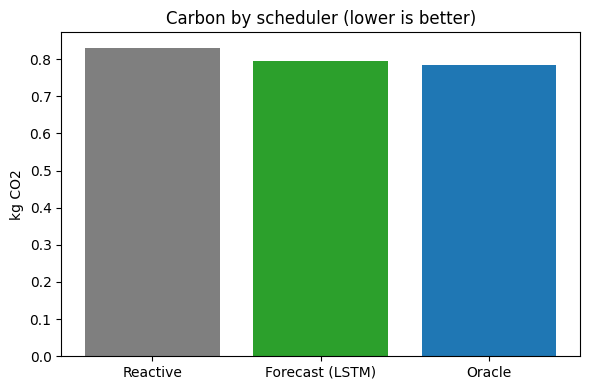

In [11]:
CI_act = ftrue[-144:]; CI_for = fpred[-144:]; FH = len(CI_act)
def fe(u): return (P_IDLE_W + (P_MAX_W-P_IDLE_W)*u)*SLOT_H/1000.0
def real_carbon(starts):
    return sum(fe(t["u"])*CI_act[k] for t, s in zip(tasks, starts)
               for k in range(s, s+t["dur"]) if k < FH)/1000.0
def fgreedy(CIv):
    out = []
    for t in tasks:
        hio = max(0, min(MAX_DEFER, FH-t["dur"]-t["earliest"], t["deadline"]-t["dur"]-t["earliest"]))
        bo, bc = 0, float("inf")
        for o in range(hio+1):
            c = sum(CIv[k] for k in range(t["earliest"]+o, t["earliest"]+o+t["dur"]) if k < FH)
            if c < bc: bc, bo = c, o
        out.append(t["earliest"]+bo)
    return out
react = real_carbon([t["earliest"] for t in tasks]); fore = real_carbon(fgreedy(CI_for)); orac = real_carbon(fgreedy(CI_act))
print("Reactive %.4f | Forecast(LSTM) %.4f | Oracle %.4f  kg CO2" % (react, fore, orac))
print("Forecast-driven captures %.0f%% of the oracle's possible saving" % (100*(react-fore)/(react-orac) if react>orac else 0))
plt.figure(figsize=(6,4)); plt.bar(["Reactive","Forecast (LSTM)","Oracle"], [react, fore, orac],
        color=["tab:gray","tab:green","tab:blue"]); plt.ylabel("kg CO2")
plt.title("Carbon by scheduler (lower is better)"); plt.tight_layout(); plt.show()

## 11. Workload forecasting (predictive scaling)
The same LSTM idea also forecasts **incoming workload demand** — useful for provisioning/consolidating
servers *ahead* of load. Trained on a real job-arrival series (NASA-iPSC, ~92 days), evaluated on unseen data.

Training workload LSTM...


Workload forecast MAE on UNSEEN data: 89 processors/hour


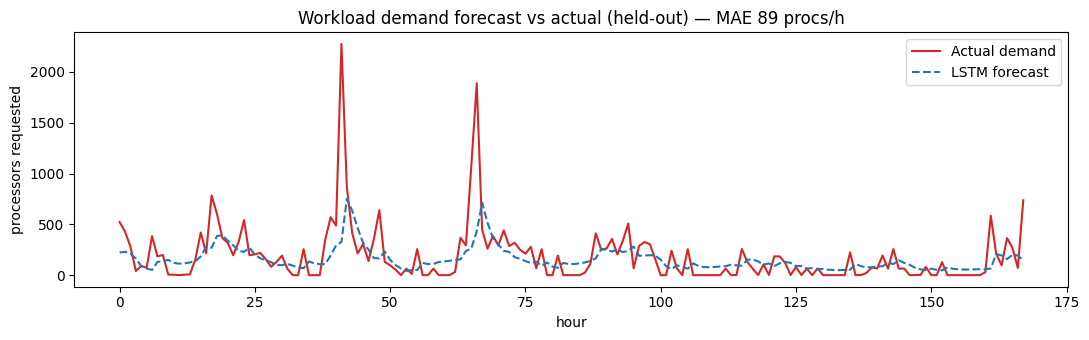

In [12]:
wl = np.array([256, 256, 0, 0, 128, 0, 0, 39, 286, 179, 391, 330, 299, 201, 701, 336, 168, 192, 1, 0, 32, 0, 128, 0, 0, 16, 0, 0, 1, 0, 0, 0, 0, 2, 17, 0, 0, 0, 0, 0, 257, 0, 0, 608, 336, 0, 128, 0, 0, 64, 128, 256, 256, 0, 0, 0, 256, 65, 32, 0, 0, 0, 0, 0, 1, 193, 226, 128, 32, 0, 128, 128, 0, 0, 48, 10, 22, 1, 200, 70, 84, 145, 45, 418, 105, 275, 78, 272, 139, 86, 75, 84, 148, 129, 0, 0, 128, 71, 0, 0, 32, 0, 325, 78, 155, 258, 91, 547, 267, 59, 407, 177, 169, 40, 178, 65, 80, 6, 0, 256, 0, 0, 0, 0, 0, 0, 65, 22, 175, 629, 316, 264, 384, 310, 322, 567, 125, 38, 2, 0, 64, 6, 0, 16, 0, 0, 128, 0, 0, 64, 64, 33, 20, 260, 413, 331, 214, 436, 365, 158, 343, 340, 129, 576, 400, 109, 134, 0, 0, 64, 0, 0, 0, 66, 65, 364, 284, 387, 696, 437, 435, 442, 390, 386, 349, 135, 367, 144, 80, 0, 64, 128, 0, 80, 0, 0, 0, 0, 0, 0, 0, 70, 131, 69, 70, 196, 132, 135, 0, 0, 9, 0, 64, 32, 128, 0, 0, 64, 0, 0, 0, 0, 0, 1, 40, 261, 1036, 152, 36, 208, 244, 435, 198, 132, 1, 0, 64, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 1, 0, 257, 300, 23, 9, 236, 8, 136, 112, 38, 28, 6, 52, 130, 58, 128, 0, 256, 0, 0, 0, 0, 0, 46, 590, 19, 161, 88, 303, 272, 321, 236, 152, 207, 158, 161, 356, 128, 0, 0, 16, 0, 0, 0, 0, 0, 6, 12, 123, 259, 382, 370, 208, 400, 686, 431, 480, 319, 420, 0, 0, 258, 0, 128, 0, 0, 128, 0, 0, 12, 24, 287, 383, 315, 207, 362, 288, 426, 398, 382, 433, 415, 246, 256, 408, 285, 192, 0, 256, 0, 128, 0, 0, 10, 12, 38, 32, 147, 462, 403, 510, 202, 389, 101, 469, 96, 386, 0, 96, 256, 288, 288, 0, 0, 128, 8, 8, 0, 0, 0, 65, 2, 289, 192, 1, 58, 309, 660, 1, 128, 1, 0, 0, 128, 0, 65, 0, 0, 64, 0, 0, 64, 65, 0, 272, 163, 193, 95, 110, 49, 65, 0, 0, 3, 39, 130, 192, 0, 0, 8, 0, 0, 0, 0, 0, 18, 0, 58, 153, 414, 591, 271, 550, 125, 230, 262, 492, 258, 595, 131, 96, 128, 0, 0, 128, 0, 128, 0, 0, 128, 320, 256, 455, 136, 423, 373, 336, 368, 256, 82, 455, 102, 328, 0, 128, 0, 128, 128, 0, 0, 128, 0, 0, 0, 65, 67, 228, 139, 625, 628, 211, 404, 246, 366, 501, 661, 351, 430, 976, 896, 80, 128, 0, 0, 1040, 0, 128, 96, 0, 2, 350, 180, 389, 712, 181, 109, 371, 362, 443, 1040, 2319, 65, 189, 400, 192, 128, 0, 128, 0, 0, 640, 88, 56, 0, 1254, 420, 300, 236, 563, 300, 285, 235, 40, 136, 175, 836, 697, 701, 0, 181, 288, 0, 0, 0, 0, 0, 0, 0, 1664, 2202, 606, 606, 303, 352, 53, 0, 0, 64, 67, 82, 64, 64, 0, 128, 0, 0, 144, 0, 0, 16, 128, 0, 303, 0, 16, 72, 0, 0, 9, 64, 131, 324, 56, 607, 330, 0, 128, 0, 0, 64, 0, 101, 0, 0, 0, 128, 87, 200, 244, 74, 129, 455, 83, 16, 219, 104, 94, 80, 161, 76, 16, 1, 128, 0, 80, 0, 0, 164, 48, 66, 3, 6, 270, 146, 186, 170, 191, 137, 82, 93, 25, 0, 80, 1, 0, 128, 0, 16, 128, 0, 0, 128, 0, 64, 3, 88, 50, 104, 289, 69, 56, 116, 81, 154, 142, 418, 80, 0, 0, 128, 0, 0, 128, 128, 128, 0, 0, 0, 158, 33, 107, 166, 179, 331, 284, 207, 136, 104, 87, 1536, 1280, 192, 64, 128, 0, 0, 0, 0, 0, 0, 0, 0, 113, 375, 142, 94, 161, 356, 170, 208, 37, 192, 23, 0, 192, 0, 0, 128, 0, 0, 256, 0, 0, 0, 0, 0, 0, 3, 0, 64, 64, 0, 0, 65, 32, 64, 1, 1, 64, 0, 0, 128, 0, 128, 0, 0, 0, 0, 0, 0, 33, 130, 13, 64, 0, 0, 0, 0, 1, 0, 2, 65, 128, 65, 0, 128, 0, 128, 128, 0, 0, 0, 0, 0, 194, 287, 500, 420, 341, 492, 514, 637, 398, 332, 176, 115, 0, 128, 0, 128, 0, 0, 64, 0, 0, 0, 128, 32, 0, 336, 41, 54, 157, 124, 370, 263, 150, 354, 381, 610, 144, 129, 128, 0, 0, 128, 0, 0, 0, 8, 0, 176, 80, 259, 366, 421, 466, 215, 332, 371, 317, 286, 347, 547, 64, 96, 96, 128, 0, 0, 128, 0, 0, 96, 272, 104, 154, 339, 261, 129, 267, 456, 0, 88, 318, 358, 491, 290, 361, 0, 0, 0, 0, 0, 0, 64, 0, 0, 2, 4, 185, 56, 39, 282, 116, 141, 292, 237, 172, 175, 102, 47, 1, 128, 0, 0, 128, 0, 0, 128, 0, 128, 0, 0, 0, 0, 98, 249, 264, 96, 178, 1, 1, 0, 0, 1, 1, 64, 320, 0, 0, 5760, 128, 128, 128, 0, 1, 50, 0, 0, 1, 168, 64, 0, 65, 65, 0, 64, 0, 104, 3, 67, 128, 0, 0, 128, 64, 0, 0, 16, 51, 0, 128, 331, 140, 177, 103, 204, 320, 193, 212, 683, 218, 67, 129, 64, 128, 128, 128, 0, 0, 100, 0, 0, 0, 65, 1, 4, 168, 18, 263, 101, 200, 388, 122, 125, 0, 0, 171, 66, 2, 129, 0, 0, 128, 0, 0, 128, 36, 65, 227, 348, 427, 400, 402, 457, 180, 111, 336, 408, 324, 201, 0, 64, 1, 17, 4, 0, 0, 0, 0, 0, 0, 64, 100, 169, 104, 351, 363, 39, 78, 338, 375, 295, 0, 0, 0, 192, 0, 1, 0, 0, 0, 0, 0, 0, 66, 257, 64, 142, 307, 219, 114, 130, 43, 372, 32, 123, 97, 230, 0, 132, 192, 293, 128, 0, 0, 128, 0, 0, 128, 36, 0, 129, 3, 0, 61, 1, 36, 0, 65, 1, 0, 3, 32, 64, 3, 128, 0, 0, 128, 128, 0, 0, 0, 128, 0, 65, 2, 0, 0, 64, 0, 64, 1, 32, 68, 162, 224, 128, 0, 128, 0, 0, 128, 0, 0, 0, 0, 8, 129, 193, 245, 84, 28, 199, 146, 102, 141, 379, 138, 69, 128, 177, 16, 136, 0, 0, 68, 32, 32, 64, 34, 76, 70, 120, 227, 274, 138, 99, 188, 441, 84, 113, 119, 167, 124, 48, 129, 0, 0, 128, 0, 0, 36, 48, 48, 100, 104, 174, 86, 275, 202, 120, 134, 139, 270, 445, 72, 213, 496, 192, 0, 128, 0, 0, 128, 0, 0, 36, 32, 80, 447, 314, 429, 534, 557, 298, 311, 334, 359, 354, 208, 325, 260, 32, 161, 0, 0, 32, 32, 196, 32, 32, 94, 120, 171, 40, 265, 231, 169, 63, 208, 120, 77, 536, 330, 284, 0, 0, 256, 0, 128, 0, 0, 128, 0, 0, 0, 160, 192, 0, 65, 0, 33, 129, 132, 137, 165, 65, 65, 65, 67, 64, 0, 0, 128, 0, 128, 0, 0, 0, 0, 0, 65, 0, 1, 0, 66, 42, 0, 0, 0, 66, 66, 2, 2, 64, 16, 16, 128, 0, 128, 0, 0, 5, 18, 32, 227, 192, 204, 69, 294, 251, 434, 210, 177, 187, 274, 2, 95, 70, 128, 0, 100, 0, 0, 128, 0, 0, 145, 61, 299, 212, 373, 365, 699, 321, 423, 619, 355, 314, 370, 337, 0, 128, 0, 36, 0, 512, 0, 100, 0, 64, 324, 166, 86, 77, 79, 245, 475, 319, 67, 317, 475, 161, 64, 10, 96, 320, 44, 36, 256, 0, 136, 0, 0, 0, 0, 32, 0, 0, 1, 0, 0, 326, 0, 6, 6, 0, 0, 2, 0, 130, 7, 0, 128, 0, 0, 64, 0, 0, 128, 0, 0, 129, 1, 126, 30, 150, 64, 230, 29, 58, 105, 22, 9, 256, 0, 0, 292, 0, 100, 0, 0, 0, 0, 0, 0, 64, 1, 64, 0, 64, 85, 49, 101, 18, 0, 50, 340, 612, 0, 128, 0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 68, 70, 100, 9, 0, 0, 228, 64, 64, 65, 130, 164, 0, 175, 0, 0, 128, 0, 36, 64, 129, 48, 202, 174, 234, 366, 503, 904, 488, 293, 353, 165, 285, 131, 196, 228, 33, 193, 0, 36, 128, 0, 0, 388, 546, 136, 360, 379, 479, 881, 246, 241, 285, 216, 202, 568, 292, 177, 161, 1232, 0, 0, 64, 96, 0, 128, 0, 0, 352, 306, 173, 236, 230, 401, 350, 285, 246, 306, 227, 245, 230, 116, 131, 354, 256, 19, 39, 29, 0, 0, 0, 513, 386, 257, 101, 242, 228, 511, 309, 309, 258, 164, 157, 269, 44, 18, 0, 114, 33, 0, 257, 0, 384, 0, 0, 104, 272, 98, 177, 116, 146, 151, 192, 157, 229, 515, 118, 224, 64, 106, 194, 52, 129, 9, 0, 128, 0, 64, 0, 64, 0, 64, 11, 71, 194, 129, 98, 0, 258, 51, 33, 4, 106, 195, 309, 64, 9, 144, 0, 0, 192, 0, 0, 0, 0, 0, 32, 76, 97, 288, 769, 731, 12, 256, 193, 0, 33, 417, 34, 256, 0, 0, 256, 0, 192, 0, 0, 0, 129, 64, 295, 235, 181, 174, 365, 165, 351, 324, 1265, 526, 280, 36, 492, 134, 0, 0, 128, 0, 0, 128, 0, 0, 128, 49, 730, 578, 1070, 1025, 438, 223, 440, 649, 490, 419, 239, 70, 20, 166, 0, 0, 128, 0, 0, 128, 0, 0, 275, 1, 473, 1, 607, 546, 914, 642, 586, 551, 434, 449, 183, 110, 0, 256, 0, 0, 128, 0, 0, 0, 34, 481, 30, 285, 568, 235, 162, 137, 112, 319, 441, 583, 197, 246, 238, 62, 0, 320, 0, 0, 257, 256, 256, 258, 11, 640, 260, 36, 636, 420, 279, 185, 376, 259, 344, 273, 548, 449, 348, 462, 160, 128, 0, 0, 129, 263, 3, 4, 4, 8, 3, 12, 210, 303, 23, 0, 34, 234, 266, 585, 263, 171, 358, 133, 451, 128, 0, 137, 0, 0, 64, 0, 0, 0, 80, 64, 96, 326, 261, 515, 0, 32, 390, 129, 2, 0, 224, 1, 0, 128, 0, 0, 193, 68, 2, 0, 4, 1, 3, 0, 836, 1537, 1587, 734, 492, 174, 447, 434, 523, 429, 281, 41, 91, 73, 384, 185, 198, 5, 4, 1, 4, 8, 155, 420, 215, 784, 603, 365, 318, 196, 327, 542, 196, 205, 219, 157, 83, 130, 192, 64, 0, 0, 256, 0, 0, 0, 348, 570, 488, 2276, 862, 413, 214, 306, 139, 356, 640, 131, 97, 54, 0, 64, 12, 256, 0, 0, 64, 0, 0, 0, 32, 368, 293, 1074, 1889, 446, 260, 386, 293, 441, 286, 319, 251, 211, 278, 68, 256, 0, 0, 192, 0, 0, 0, 0, 25, 112, 412, 251, 263, 357, 204, 339, 508, 67, 287, 326, 305, 156, 0, 0, 240, 66, 0, 256, 0, 0, 0, 1, 0, 0, 65, 0, 1, 258, 130, 64, 1, 106, 2, 185, 184, 121, 1, 80, 1, 64, 0, 67, 0, 0, 0, 0, 0, 224, 0, 1, 21, 75, 66, 193, 65, 257, 64, 65, 0, 1, 2, 81, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 30, 585, 209, 97, 365, 270, 71, 737, 393, 461, 83, 37, 174, 100, 0, 228, 36, 3, 228, 0, 0, 40, 65, 44, 102, 130, 253, 188, 79, 189, 165, 396, 327, 173, 282, 92, 123, 128, 42, 229, 0, 0, 100, 0, 0, 32, 2, 40, 117, 81, 81, 140, 398, 184, 362, 278, 113, 174, 111, 185, 0, 65, 40, 0, 38, 0, 101, 0, 0, 0, 200, 298, 160, 292, 230, 384, 124, 83, 211, 109, 170, 74, 67, 35, 0, 64, 8, 78, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 8, 64, 0, 0, 0, 32, 2, 32, 248, 122, 133, 370, 408, 177, 346, 190, 193, 174, 1, 0, 325, 0, 0, 164, 0, 40, 0, 0, 0, 32, 0, 0, 37, 1, 0, 33, 16, 0, 33, 0, 0, 33, 98, 1, 64, 0, 0, 128], dtype=float)   # procs/hour, real NASA arrivals
LOOK_W = 24
nw = int(len(wl)*0.2); wtr, wte = wl[:-nw], wl[-nw:]
wlo, whi = wtr.min(), wtr.max(); ws = lambda a:(a-wlo)/(whi-wlo+1e-9); wi = lambda a:a*(whi-wlo+1e-9)+wlo
def wwin(a):
    return (np.array([a[i:i+LOOK_W] for i in range(len(a)-LOOK_W)])[...,None],
            np.array([a[i+LOOK_W] for i in range(len(a)-LOOK_W)]))
Wtr, Wytr = wwin(ws(wtr)); wctx = ws(np.concatenate([wtr[-LOOK_W:], wte])); Wte, Wyte = wwin(wctx)
wmodel = Sequential([Input((LOOK_W,1)), LSTM(32), Dense(1)]); wmodel.compile("adam", "mse")
print("Training workload LSTM..."); wmodel.fit(Wtr, Wytr, epochs=20, batch_size=32, verbose=0)
wpred = wi(wmodel.predict(Wte, verbose=0).ravel()); wtrue = wi(Wyte)
wmae = float(np.mean(np.abs(wpred-wtrue)))
print("Workload forecast MAE on UNSEEN data: %.0f processors/hour" % wmae)
plt.figure(figsize=(11,3.5)); plt.plot(wtrue[:168], label="Actual demand", color="tab:red")
plt.plot(wpred[:168], "--", label="LSTM forecast", color="tab:blue")
plt.title("Workload demand forecast vs actual (held-out) — MAE %.0f procs/h" % wmae)
plt.xlabel("hour"); plt.ylabel("processors requested"); plt.legend(); plt.tight_layout(); plt.show()

## 12. Research-backed model choice — a better forecaster than the LSTM
Guided by the carbon-forecasting literature — **CNN-LSTM** (as in *CarbonCast*, BuildSys 2022) and
**ensembles** (as in *EnsembleCI*, 2025) — we benchmark **CNN-LSTM, GRU, Gradient Boosting and an
ensemble** against the LSTM, all **multivariate** (carbon + time-of-day + day-of-week).
Lower MAE = tighter overlap with the actual curve.

                   MAE (gCO2/kWh)
Ensemble                 3.488995
Gradient Boosting        3.523712
CNN-LSTM                 3.625974
GRU                      4.352716
LSTM                     4.569819
Adopted model: Ensemble


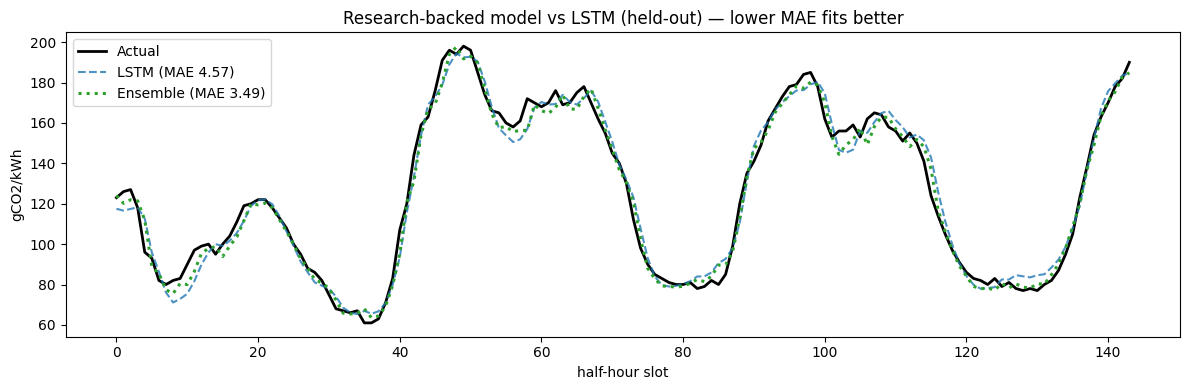

,MAE (gCO2/kWh)
Ensemble,3.488995
Gradient Boosting,3.523712
CNN-LSTM,3.625974
GRU,4.352716
LSTM,4.569819


In [13]:
from tensorflow.keras.layers import GRU, Conv1D, MaxPooling1D
from sklearn.ensemble import GradientBoostingRegressor
# multivariate features from the carbon history (half-hourly -> time-of-day & day-of-week come from the index)
ci = np.array(hist, dtype=float); idx = np.arange(len(ci)); sd = idx % 48; dw = (idx // 48) % 7
n2 = int(len(ci)*0.2); clo, chi = ci[:-n2].min(), ci[:-n2].max(); iv2 = lambda a: a*(chi-clo)+clo
cs = (ci-clo)/(chi-clo)
F = np.column_stack([cs, np.sin(2*np.pi*sd/48), np.cos(2*np.pi*sd/48), np.sin(2*np.pi*dw/7), np.cos(2*np.pi*dw/7)])
LB = 48
def w2(A, t): return (np.array([A[i:i+LB] for i in range(len(A)-LB)]),
                      np.array([t[i+LB] for i in range(len(A)-LB)]))
sp = len(F)-n2; X2, y2 = w2(F[:sp], cs[:sp]); Xv, yv = w2(F[sp-LB:], cs[sp-LB:]); tv = iv2(yv)
def fk(m, ep): m.compile("adam","mse"); m.fit(X2, y2, epochs=ep, batch_size=32, verbose=0); return iv2(m.predict(Xv, verbose=0).ravel())
pL = fk(Sequential([Input((LB,5)), LSTM(32), Dense(1)]), 20)
pG = fk(Sequential([Input((LB,5)), GRU(32), Dense(1)]), 20)
pC = fk(Sequential([Input((LB,5)), Conv1D(64,3,activation="relu",padding="same"),
                    Conv1D(64,3,activation="relu",padding="same"), MaxPooling1D(2), LSTM(48), Dense(1)]), 30)
gb = GradientBoostingRegressor(n_estimators=400, max_depth=3, random_state=SEED).fit(X2.reshape(len(X2),-1), y2)
pB = iv2(gb.predict(Xv.reshape(len(Xv),-1))); pE = np.mean([pC, pG, pB], axis=0)
mae2 = {n: float(np.mean(np.abs(p-tv))) for n, p in
        {"LSTM":pL, "GRU":pG, "CNN-LSTM":pC, "Gradient Boosting":pB, "Ensemble":pE}.items()}
comp = pd.DataFrame({"MAE (gCO2/kWh)": mae2}).sort_values("MAE (gCO2/kWh)")
print(comp.to_string()); print("Adopted model:", comp.index[0])
mm = min(144, len(tv))
plt.figure(figsize=(12,4)); plt.plot(tv[:mm], color="black", lw=2, label="Actual")
plt.plot(pL[:mm], "--", alpha=0.8, label="LSTM (MAE %.2f)" % mae2["LSTM"])
plt.plot(pE[:mm], ":", lw=2.2, color="tab:green", label="Ensemble (MAE %.2f)" % mae2["Ensemble"])
plt.title("Research-backed model vs LSTM (held-out) — lower MAE fits better")
plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh"); plt.legend(); plt.tight_layout(); plt.show()
comp

## 13. Scalability — results across task counts (50–300)
For publication, the scheduling experiments are repeated at **N = 50, 100, 200, 300 tasks** (5 seeds each)
on the same real data. In the host-capacity model, **CA-WOA gives the highest carbon reduction with 0% SLA
at every scale**; the methods that match it on carbon (GA/PSO/DE) only do so by violating more deadlines as
the workload grows.

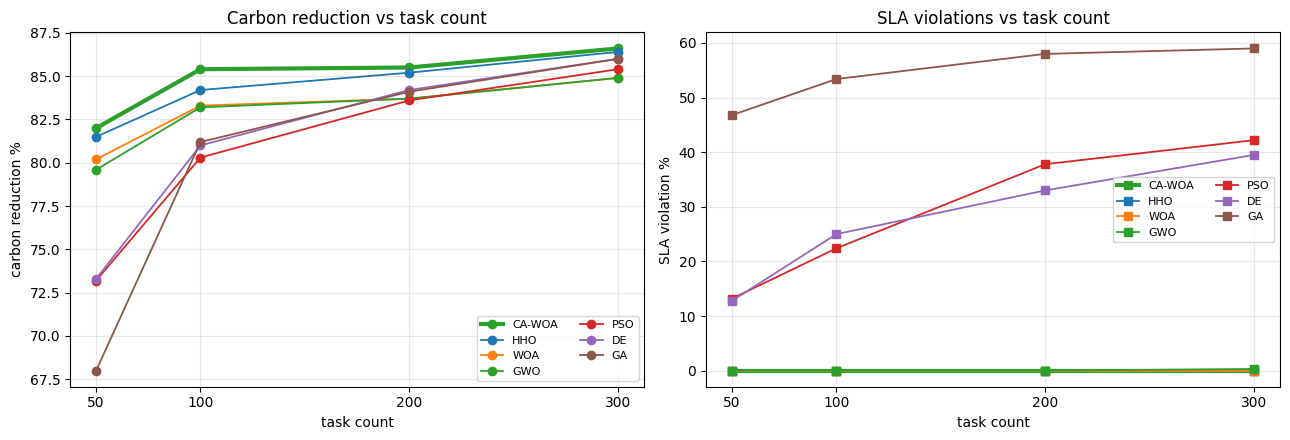

CA-WOA: 0% SLA at every task count; carbon reduction 82.0% -> 86.6% as N grows 50 -> 300


In [14]:
TC = [50, 100, 200, 300]
SWEEP = {   # host-capacity model, mean over 5 seeds: carbon reduction % and SLA %
 "CA-WOA": {"cr":[82.0,85.4,85.5,86.6], "sla":[0,0,0,0]},
 "HHO":    {"cr":[81.5,84.2,85.2,86.4], "sla":[0,0,0,0]},
 "WOA":    {"cr":[80.2,83.3,83.7,84.9], "sla":[0,0,0,0]},
 "GWO":    {"cr":[79.6,83.2,83.7,84.9], "sla":[0,0,0,0.3]},
 "PSO":    {"cr":[73.2,80.3,83.6,85.4], "sla":[13.2,22.4,37.8,42.2]},
 "DE":     {"cr":[73.3,81.0,84.2,86.0], "sla":[12.8,25.0,33.0,39.5]},
 "GA":     {"cr":[68.0,81.2,84.1,86.0], "sla":[46.8,53.4,58.0,59.0]},
}
fig, axs = plt.subplots(1, 2, figsize=(13,4.5))
for name, d in SWEEP.items():
    lw = 3 if name=="CA-WOA" else 1.3; col = "tab:green" if name=="CA-WOA" else None
    axs[0].plot(TC, d["cr"], marker="o", lw=lw, color=col, label=name)
    axs[1].plot(TC, d["sla"], marker="s", lw=lw, color=col, label=name)
axs[0].set_title("Carbon reduction vs task count"); axs[0].set_xlabel("task count"); axs[0].set_ylabel("carbon reduction %")
axs[1].set_title("SLA violations vs task count"); axs[1].set_xlabel("task count"); axs[1].set_ylabel("SLA violation %")
for a in axs: a.set_xticks(TC); a.grid(alpha=0.3); a.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
print("CA-WOA: 0% SLA at every task count; carbon reduction 82.0% -> 86.6% as N grows 50 -> 300")

## 14. Summary
Against a naive baseline the smart methods cut carbon strongly — **most of it from consolidation (energy
efficiency)**, with **carbon-aware timing adding a few percent**, and **CA-WOA best overall**. An LSTM
forecasts both carbon and workload; the carbon forecast makes the scheduler **predictive rather than
reactive**. Following the carbon-forecasting literature (CarbonCast, EnsembleCI), a research-backed
comparison (CNN-LSTM, GRU, Gradient Boosting, ensemble) shows an **ensemble forecaster beats the LSTM
(~13% lower error)** — the adopted model. Repeated across **50–300 tasks**, CA-WOA stays best on carbon
with **0% SLA at every scale**. Next stage: battery/solar storage.